In [16]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import pandas as pd
import numpy as np
import anndata
import scanpy as sc
import seaborn as sns
from adjustText import adjust_text
from tqdm import tqdm
from scipy.cluster.hierarchy import linkage, dendrogram, ClusterNode, to_tree

In [3]:
# Load Xenium data using stlearn
adata = st.ReadXenium(
    feature_cell_matrix_file="../tutorial_data/xenium_data/cell_feature_matrix.h5",
    cell_summary_file="../tutorial_data/xenium_data/cells.csv.gz",
    library_id="example data",
    image_path=None,
    scale=1,
    spot_diameter_fullres=10
)

In [4]:
# Gridding at 10μm interval using stlearn
N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)

In [5]:
from scomv.preparation.skny_calc_distance import calculate_distance

In [6]:
## apply SKNY
grid = calculate_distance(
    grid, pos_marker_ls=['CDH1',"EPCAM"],
)

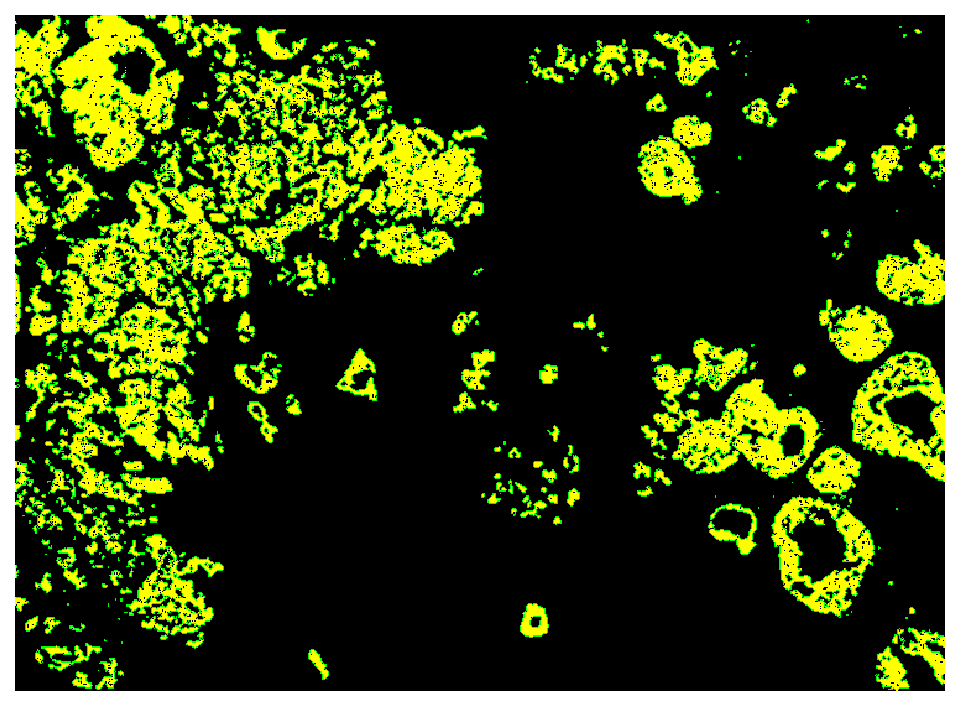

In [7]:
# Figure 2B
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.imshow(cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB),
          interpolation="nearest")
ax.axis("off")
plt.show()

#plt.savefig("Figure_2B.png", dpi=300)

In [8]:
# annotation each section to obs object
df_shotest = getattr(grid, "shortest")
df_grid = grid.to_df()

# extract grid info
df_grid = pd.merge(
    pd.DataFrame(index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)]),
    df_grid, right_index=True, left_index=True, how="left"
).fillna(np.nan)

# extract section info
df_region = pd.DataFrame(
    np.array(df_shotest["region"]).reshape(N_ROW, N_COL).T.reshape(N_ROW * N_COL),
    index=["grid_" + str(i+1) for i in range(N_ROW * N_COL)], columns=["region"]
)

# marge
df_grid_region = pd.merge(
    df_grid, df_region,
    right_index=True, left_index=True, how="left"
)
df_grid_region = df_grid_region.dropna()

# add to obs
grid.obs = pd.merge(
    grid.obs, df_grid_region[["region"]],
    right_index=True, left_index=True, how="left"
)

# shaping
grid.obs["region_10"] = [str(i*10) for i in grid.obs["region"]]
grid.obs["region_10"] = ["("+str(int(float(i.split(", ")[0][1:])))+", "+str(int(float(i.split(", ")[-1][:-1])))+"]" if i != "nan" else np.nan for i in grid.obs["region_10"]]
# exclude because of small number
grid.obs["region_10"] = grid.obs["region_10"].replace(
    {"(-150, -120]": np.nan}
)

In [9]:
from scomv.gene import run_full_pipeline

roi_list = [
    (4800, 5900, 950, 1900),
    (6920, 7570, 1910, 2390),
    (5300, 6400, 3050, 3900),
    (6050, 7050, 3910, 5100),
    (3900, 4500, 4600, 5200),
    (2400, 3400, 2400, 3800),
    (2700, 4000, 750, 1690),
    (1000, 2100, 1700, 2500),
    (400, 1500, 3600, 4200),
    (900, 1700, 4200, 5300),
    
]

In [10]:
results = []
dfs = []

for roi in tqdm(roi_list, desc="Running ROI pipelines"):
    res = run_full_pipeline(
        adata=adata,
        grid=grid,
        roi=roi,
        min_gene_percentile=30,
        max_gene_percentile=95,
        require_moran_nonneg=True,
    )
    results.append(res)
    dfs.append(res["dist_df"])


Running ROI pipelines:   0%|                                                                                             | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?/s]

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
Running ROI pipelines:  10%|████████▌                                                                            | 1/10 [00:16<02:25, 16.22s/it]/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 1 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


  0%|          | 0/100 [00:00<?, ?/s]

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
Running ROI pipelines:  20%|█████████████████                                                                    | 2/10 [00:29<01:58, 14.78s/it]/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 1 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


...

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
Running ROI pipelines:  80%|████████████████████████████████████████████████████████████████████                 | 8/10 [02:16<00:35, 17.68s/it]

  0%|          | 0/100 [00:00<?, ?/s]

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
Running ROI pipelines:  90%|████████████████████████████████████████████████████████████████████████████▌        | 9/10 [02:31<00:16, 16.85s/it]

  0%|          | 0/100 [00:00<?, ?/s]

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
Running ROI pipelines: 100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:48<00:00, 16.82s/it]


In [11]:
common_genes = set.intersection(*[set(df.index) for df in dfs])

print(f"the number of common genes: {len(common_genes)}")

for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[sorted(common_genes), sorted(common_genes)]

the number of common genes: 157


In [12]:
from sklearn.decomposition import NMF
from scomv.nmf import SymNMF

n_components = 1

W_results = {}
H_results = {}

    
rng = np.random.default_rng(123)

for i, df in enumerate(dfs):
    min_x, max_x, min_y, max_y  = roi_list[i]

    key = f"{min_x}<x<{max_x}, {min_y}<y<{max_y}"
    A = df.to_numpy()
    sigma = np.abs(rng.normal(scale=0.1, size=A.size)).reshape(A.shape)
    A = A + (sigma + sigma.T)/2

    snmf = SymNMF(k=1, random_state=123)
    snmf.fit(A)

    H_results[key] = snmf.H


In [13]:
feature_matrix = []
keys = []

for key, H in H_results.items():
    mean_vec = H.mean(axis=1)
    feature_matrix.append(mean_vec)
    keys.append(key)

feature_matrix = np.array(feature_matrix)

In [14]:
from sklearn.cluster import KMeans

n_clusters = 3  # define the number of cluster
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(feature_matrix)

print("the result of clustering:", clusters)


the result of clustering: [2 2 2 2 0 0 1 1 1 1]


In [17]:
annotation_dist = {}
annotation_dist["4800<x<5900, 950<y<1900"]= "1 (DCIS)"
annotation_dist["6920<x<7570, 1910<y<2390"]= "2 (DCIS)"
annotation_dist["5300<x<6400, 3050<y<3900"]= "3 (DCIS)"
annotation_dist["6050<x<7050, 3910<y<5100"]= "4 (DCIS)"
annotation_dist["3900<x<4500, 4600<y<5200"]= "5 (DCIS)"
annotation_dist["2400<x<3400, 2400<y<3800"]= "6 (DCIS)"

annotation_dist["2700<x<4000, 750<y<1690"]= "7 (IDC)"
annotation_dist["1000<x<2100, 1700<y<2500"]= "8 (IDC)"
annotation_dist["400<x<1500, 3600<y<4200"]= "9 (IDC)"
annotation_dist["900<x<1700, 4200<y<5300"]= "10 (IDC)"


# ======== Prepare data for clustering ========
feature_matrix = []
keys = []

for key, H in H_results.items():
    # H: shape = (n_components, n_samples)
    mean_vec = H.mean(axis=1)
    feature_matrix.append(mean_vec)
    keys.append(key)

feature_matrix = np.array(feature_matrix)

# ======== KMeans clustering ========
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(feature_matrix)
print("Clustering results (groups of 10 datasets):", clusters)

# ======== Hierarchical clustering ========
labels = [f"ROI{annotation_dist[key]}" for key in keys]
Z = linkage(feature_matrix, method="average")

Clustering results (groups of 10 datasets): [2 2 2 2 0 0 1 1 1 1]


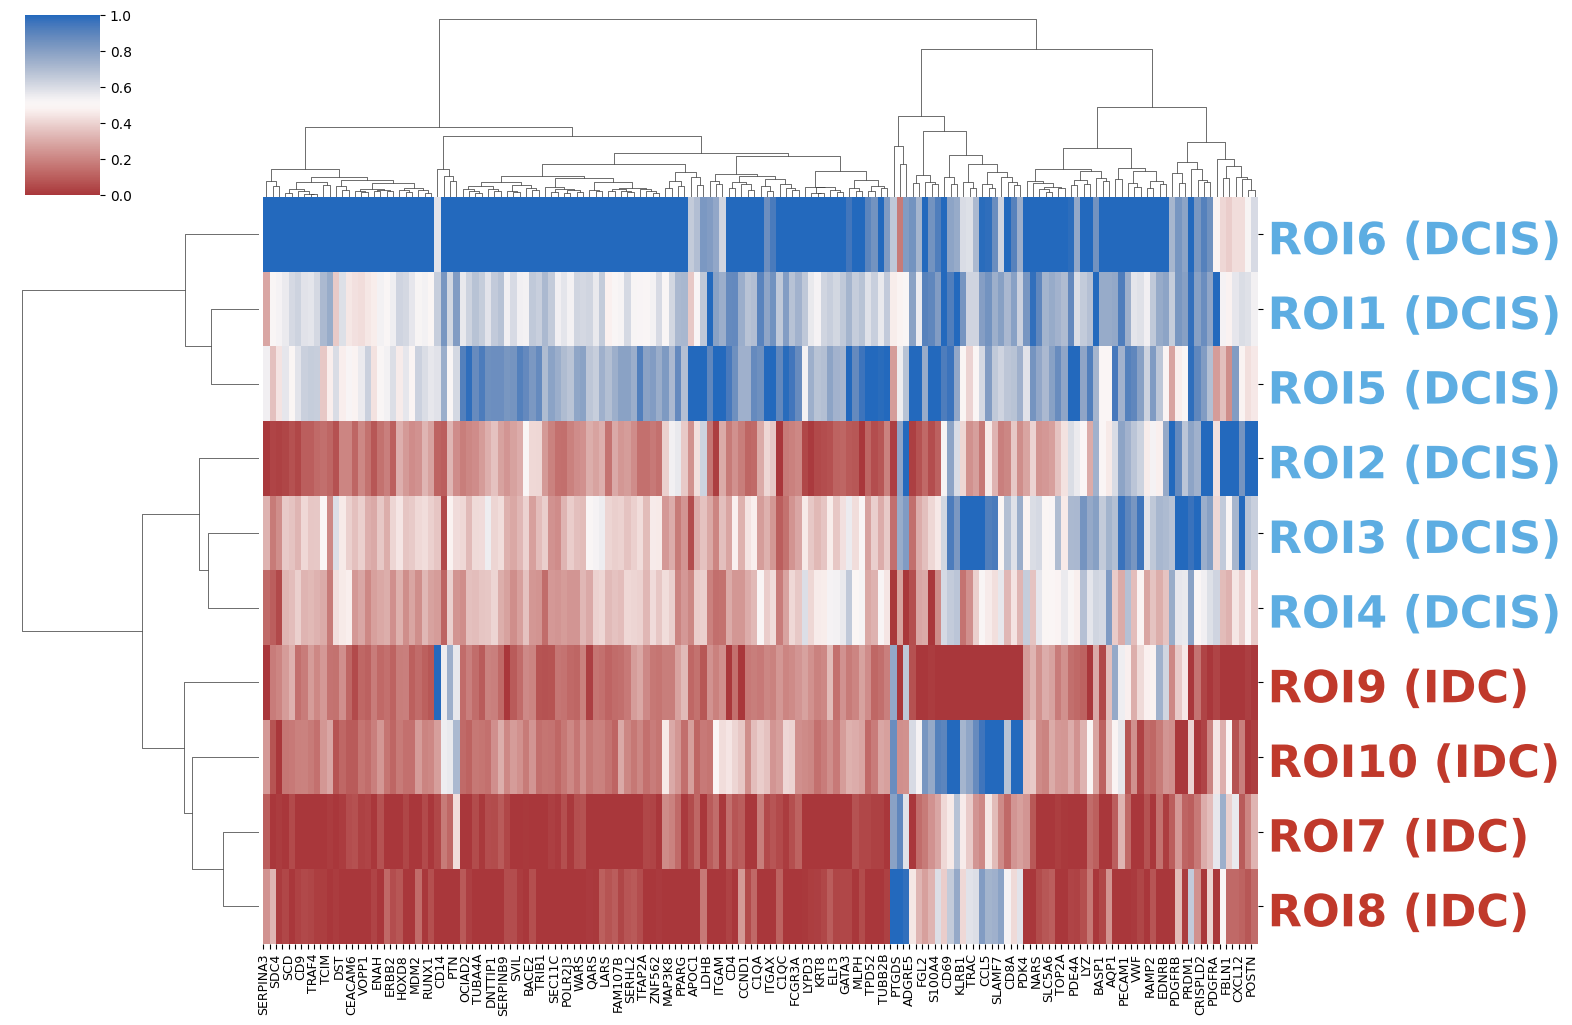

In [18]:
import matplotlib.patheffects as pe

df_features = pd.DataFrame(feature_matrix, index=keys)
labels = [f"ROI{annotation_dist[key]}" for key in keys]
new_dict = {i: g for i, g in enumerate(sorted(common_genes))}

cg = sns.clustermap(
    df_features,
    method='ward',
    metric='euclidean',
    cmap='vlag_r',
    standard_scale=1,
    figsize=(15, 10),
    dendrogram_ratio=(0.2, 0.2),
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)

new_order = cg.dendrogram_row.reordered_ind
ax = cg.ax_heatmap

# ---------- Prepare row labels ----------
yticklabels = [labels[i] for i in new_order]

# Remove original y-axis tick labels
ax.set_yticklabels([])

# Get current y-tick positions (row centers)
yticks = ax.get_yticks()

# Define vertical offset for label positioning
# Positive values shift labels downward
dy = +0.1  # Try values such as -0.1, -0.2, -0.5 if needed

for y, lab in zip(yticks, yticklabels):

    # ---- Color labels by DCIS / IDC ----
    if "DCIS" in lab:
        color = "#5DADE2"
    elif "IDC" in lab:
        color = "#C0392B"
    else:
        color = "black"

    ax.text(
        1.01,
        y + dy,
        lab,
        transform=ax.get_yaxis_transform(),  # x in axes coordinates, y in data coordinates
        ha='left',
        va='center',
        fontsize=32,
        fontweight='bold',
        color=color,
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

# ---------- Column labels (same as before) ----------
new_order_col = cg.dendrogram_col.reordered_ind
xticklabels = [new_dict[i] for i in new_order_col]
xticklabels_sparse = [
    label if (idx % 2 == 0) else ''
    for idx, label in enumerate(xticklabels)
]

ax.set_xticks(range(len(xticklabels_sparse)))
ax.set_xticklabels(xticklabels_sparse, rotation=90, fontsize=9)

# plt.savefig("heatmap_20251117.png", dpi=300, bbox_inches='tight')
plt.show()


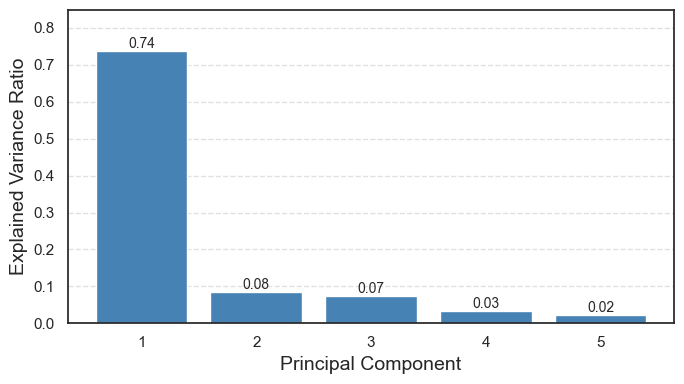

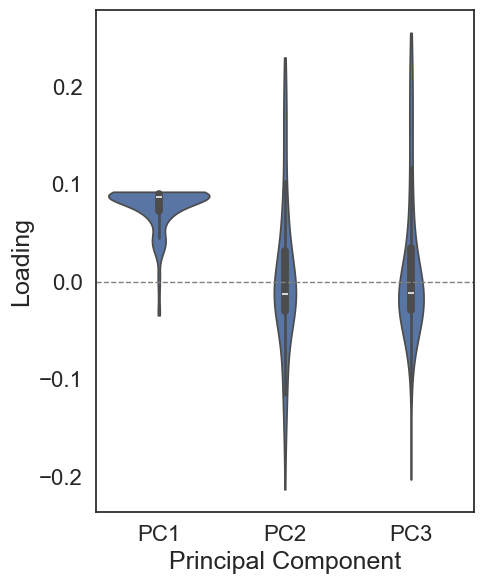

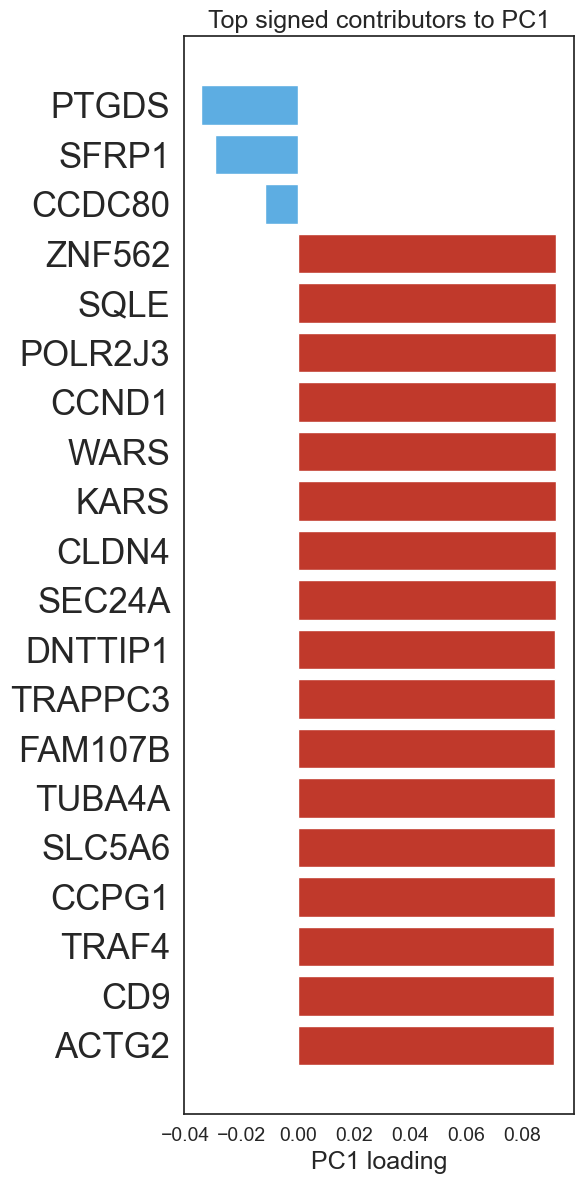

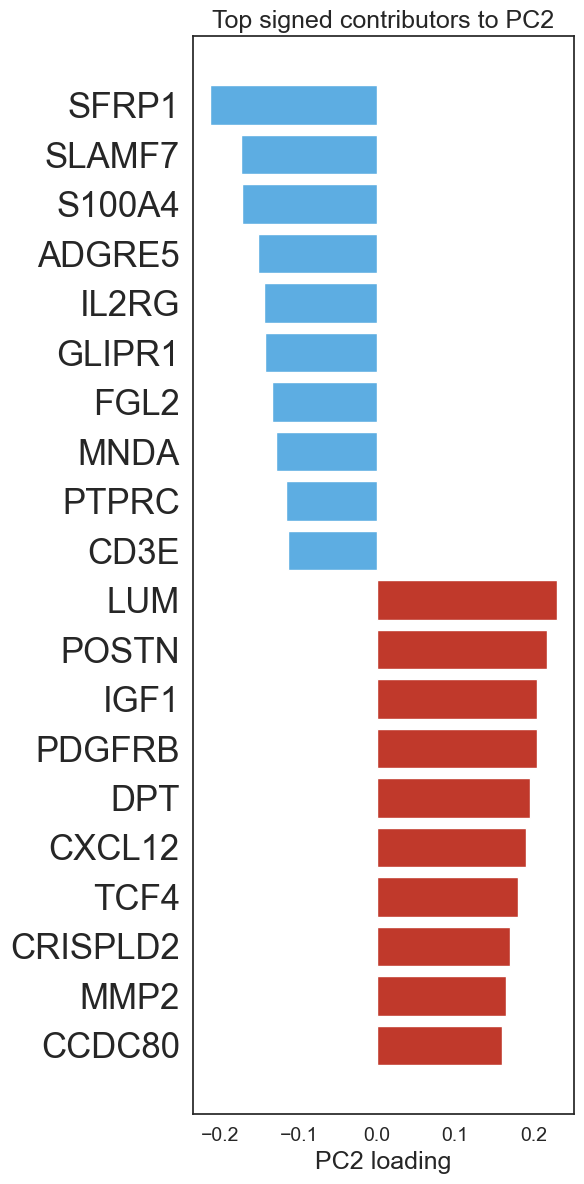

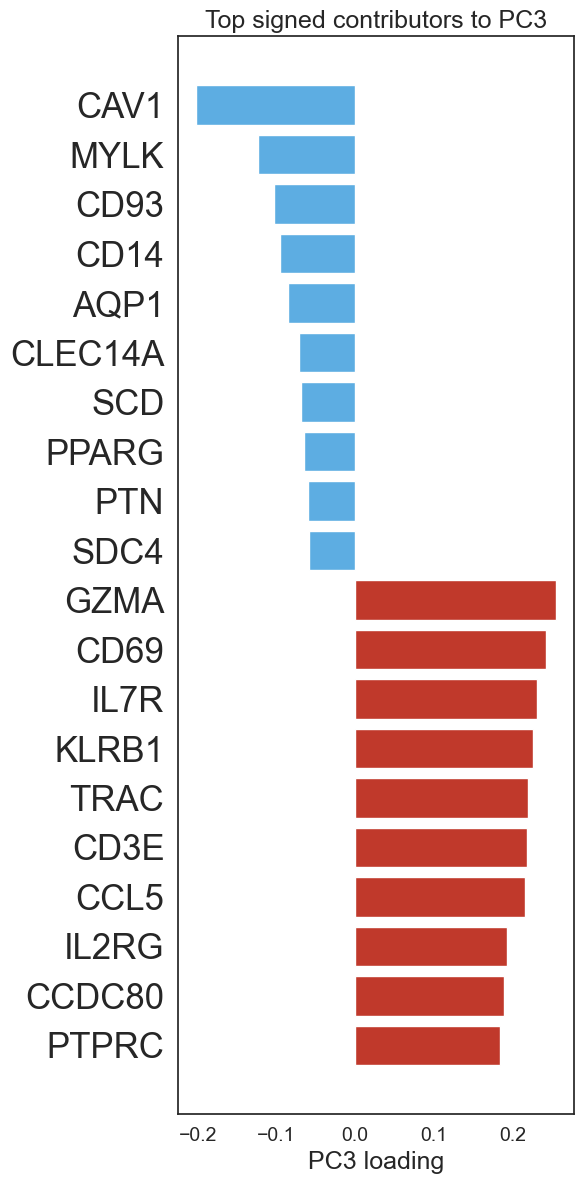

In [19]:
from scomv.spatial_deg import Spatial_DEG

report = Spatial_DEG(n_components=5, standardize=True).fit(
    feature_matrix,
    feature_names=list(new_dict.values())
)

sns.set_theme(style="white")

# 1) Cumulative explained variance
report.plot_explained_variance_bar(max_pc=10)

# 2) Violin plots of loadings (PC1–PC3)
report.plot_loading_violin(pcs=(0, 1, 2))

# 3) Signed top contributing genes for PC1, PC2, and PC3 (bar plots)
report.plot_signed_top_contributions_multi(pcs=(0, 1, 2), top_pos=10, top_neg=10)

# Retrieve top positively and negatively contributing genes
top_df = report.get_top_genes_signed(pcs=(0, 1, 2), top_pos=10, top_neg=10)

# Extract unique genes from the top contributors
top_pca_genes = top_df["gene"].drop_duplicates().tolist()

# Exclude PC1 and keep genes ranked within top 5
top_df = top_df[(top_df["PC"] != "PC1") & (top_df["rank"] <= 5)]

# Final list of top PCA-associated genes
top_pca_genes = top_df["gene"].drop_duplicates().tolist()

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/riuyamas/miniconda3/envs/sc-test310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



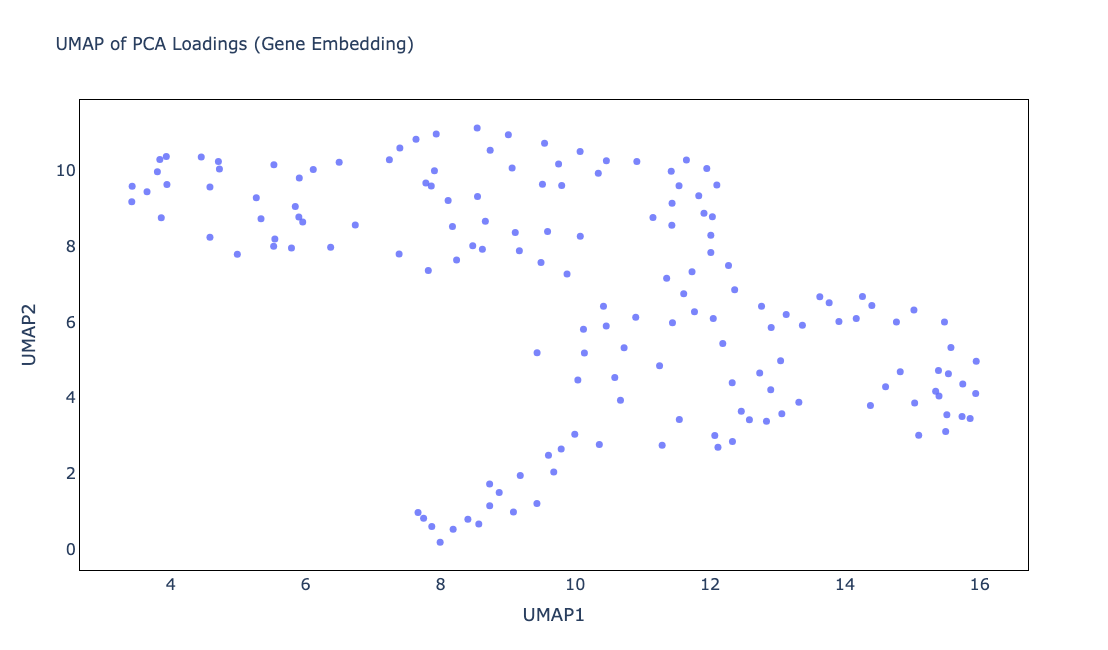

In [41]:
report = Spatial_DEG(n_components=3, standardize=True).fit(
    feature_matrix,
    feature_names=common_genes
)

# 1) conduct UMAP
umap_df = report.fit_umap_on_loadings(
    n_neighbors=10,
    min_dist=0.5,
    random_state=42,
)

# 2) show 2D maps
report.plot_umap_loadings_interactive(umap_df)


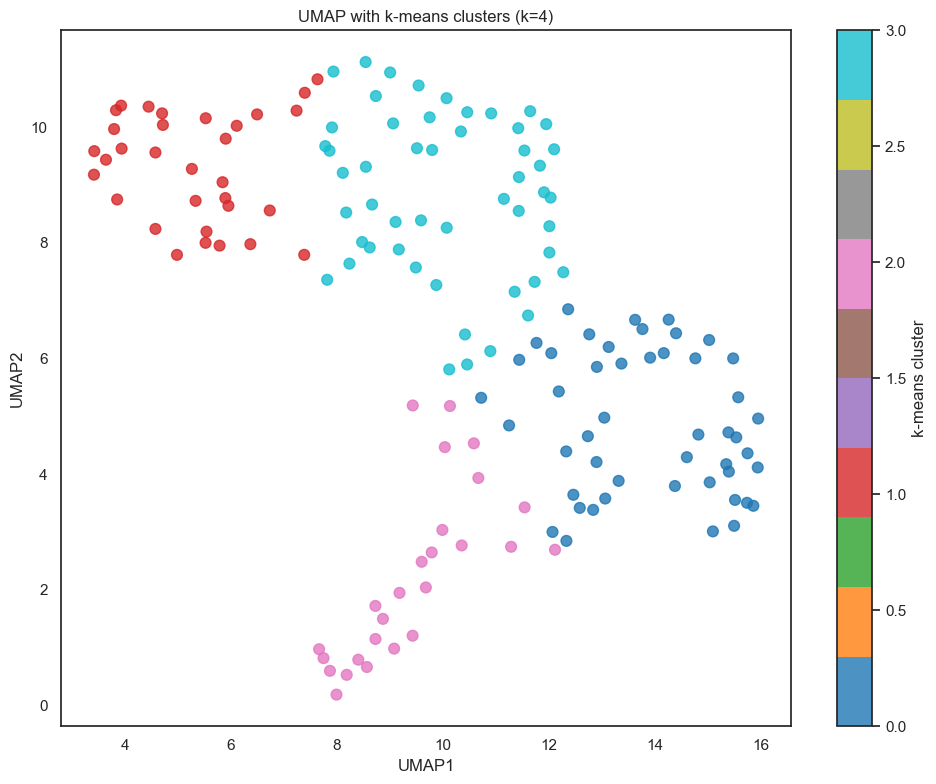

In [42]:
# Extract UMAP coordinates
X = umap_df[["UMAP1", "UMAP2"]].values

# k-means（4クラスタ）
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Add the results to the DataFrame
umap_df["kmeans_cluster"] = cluster_labels

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    c=umap_df["kmeans_cluster"],
    cmap="tab10",
    s=60,
    alpha=0.8
)
plt.colorbar(scatter, label="k-means cluster")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP with k-means clusters (k=4)")
plt.tight_layout()
plt.show()


In [43]:
# Load the file containing spatial distribution annotations
annotation_path = "../tutorial_data/breast_gene_annotate.csv"
annotate_df = pd.read_csv(annotation_path)

## Label PCoA components
def add_info(clu_num, names, gene_name, doubt_info , selected_genes):
    if gene_name in selected_genes:
    #if gene_name in selected_genes:
        # Convert labels from 1–6 to 0-based indexing by subtracting 1
        index_ = int(clu_num) - 1
        names[index_].append(gene_name)


names = [[] for i in range(6)]
for i in range(annotate_df.shape[0]):
    clu_num = annotate_df.iloc[i, 1]
    if not clu_num ==  'NaN':
        gene_name = annotate_df.iloc[i, 0]
        doubt_info = annotate_df.iloc[i, 2]
        add_info(clu_num, names, gene_name, doubt_info, common_genes)

pheris = names[0]
print(f"pheri: {len(pheris)}")
insides = names[1]
print(f"inside: {len(insides)}")
lows = names[2]
print(f"low: {len(lows)}")
ubi_in = names[3]
print(f"ubi_in: {len(ubi_in)}")
ubi_out = names[4]
print(f"ubi_out: {len(ubi_out)}")

label_df = annotate_df.iloc[:, :2]
label_df.columns = ["label", "gene"]

for index_name in umap_df.index:
    if index_name in names[0]:
        umap_df.loc[index_name, 'annotation'] = "peripheral"
    elif index_name in names[1]:
        umap_df.loc[index_name, 'annotation'] = "internal"
    elif index_name in names[2]:
        umap_df.loc[index_name, 'annotation'] = "low"
    elif index_name in names[3]:
        umap_df.loc[index_name, 'annotation'] = "ubiquitous (include internal)"
    elif index_name in names[4]:
        umap_df.loc[index_name, 'annotation'] = "ubiquitous (not include internal)"


pheri: 54
inside: 39
low: 0
ubi_in: 43
ubi_out: 21


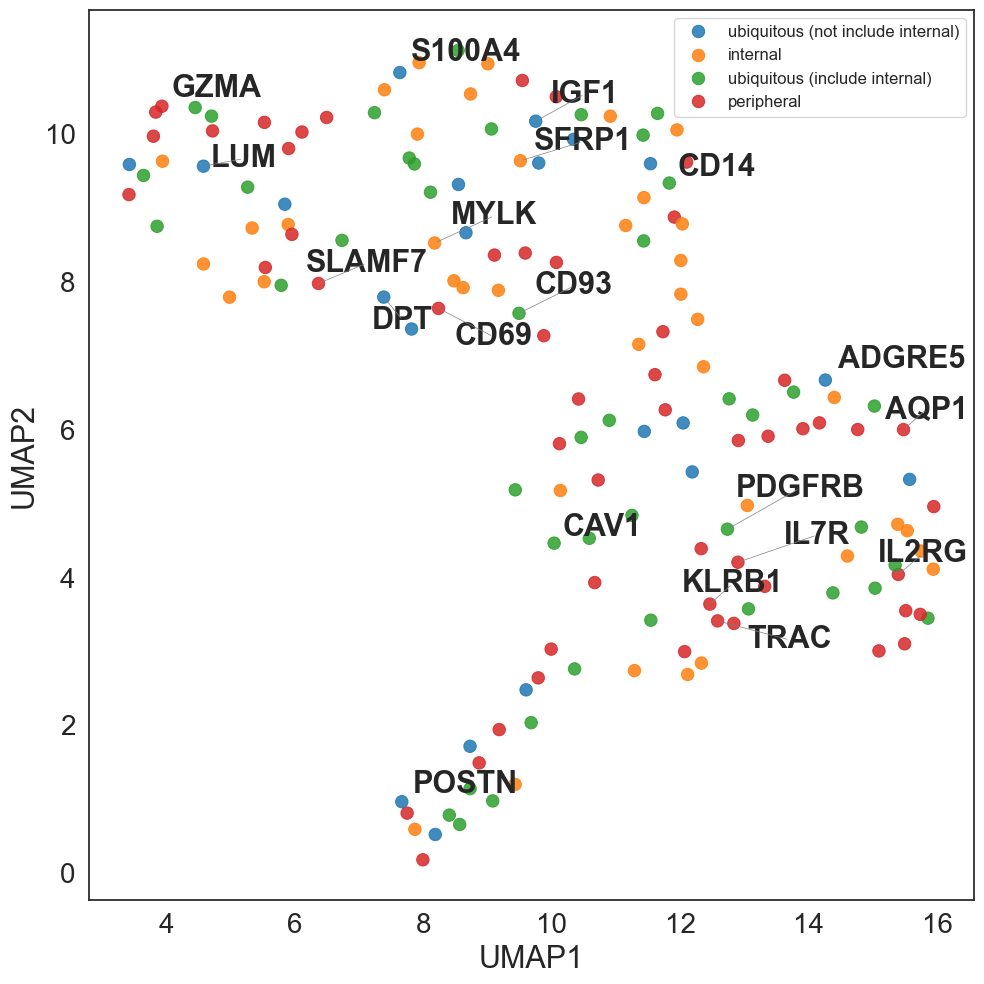

In [44]:
plt.figure(figsize=(10, 10), facecolor="white")

palette = {
    "peripheral": "tab:red",
    "internal": "tab:orange",
    "ubiquitous (include internal)": "tab:green",
    "ubiquitous (not include internal)": "tab:blue"
}

# --- Scatter plot colored by annotation ---
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="annotation",
    palette=palette,
    s=80,
    alpha=0.85,
    edgecolor=None,
)

texts = []
for gene, row in umap_df.iterrows():
    if gene in top_pca_genes:
        texts.append(
            plt.text(
                row["UMAP1"],
                row["UMAP2"],
                gene,
                fontsize=22,
                fontweight="bold"
            )
        )

# --- Avoid label overlap using adjustText ---
adjust_text(
    texts,
    only_move={'points': 'y', 'text': 'xy'},
    force_text=1.5,
    force_points=1.0,
    expand_text=(1.2, 1.3),
    expand_points=(1.2, 1.3),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

# Axes and labels
plt.xlabel("UMAP1", fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel("UMAP2", fontsize=22)
plt.yticks(fontsize=20)
# plt.title("UMAP Gene Embedding Colored by Annotation", fontsize=20)

plt.legend(fontsize=12, loc="best")
plt.tight_layout()
plt.show()


In [36]:
top_df = top_df[(top_df["PC"] != "PC1") & (top_df["rank"] <= 5)]
top_pca_genes = top_df["gene"].drop_duplicates().tolist()

In [25]:
# DEG analysis
import scanpy as sc

region1 = (grid.obs["imagecol"].between(4800, 5900)) & (grid.obs["imagerow"].between(950, 1900))
region2 = (grid.obs["imagecol"].between(6920, 7570)) & (grid.obs["imagerow"].between(1910, 2390))
region3 = (grid.obs["imagecol"].between(5300, 6400)) & (grid.obs["imagerow"].between(3050, 3900))
region4 = (grid.obs["imagecol"].between(6050, 7050)) & (grid.obs["imagerow"].between(3910, 5100))
region5 = (grid.obs["imagecol"].between(3900, 4500)) & (grid.obs["imagerow"].between(4600, 5200))
region6 = (grid.obs["imagecol"].between(2400, 3400)) & (grid.obs["imagerow"].between(2400, 3800))

region7 = (grid.obs["imagecol"].between(2700, 4000)) & (grid.obs["imagerow"].between(750, 1690))
region8 = (grid.obs["imagecol"].between(1000, 2100)) & (grid.obs["imagerow"].between(750, 1690))
region9 = (grid.obs["imagecol"].between(400, 1500)) & (grid.obs["imagerow"].between(3600, 4200))
region10 = (grid.obs["imagecol"].between(900, 1700)) & (grid.obs["imagerow"].between(3600, 4200))


grid.obs["deg_group"] = None

# Labeling
grid.obs.loc[region1, "deg_group"] = 1
grid.obs.loc[region2, "deg_group"] = 2
grid.obs.loc[region3, "deg_group"] = 3
grid.obs.loc[region4, "deg_group"] = 4
grid.obs.loc[region5, "deg_group"] = 5
grid.obs.loc[region6, "deg_group"] = 6

grid.obs.loc[region7, "deg_group"] = 7
grid.obs.loc[region8, "deg_group"] = 8
grid.obs.loc[region9, "deg_group"] = 9
grid.obs.loc[region10, "deg_group"] = 10

grid.obs["deg_group_merged"] = grid.obs["deg_group"].map({
    1: "A",
    2: "A",
    3: "A",
    4: "A",
    5: "A",
    6: "A",
    
    7: "B",  
    8: "B",
    9: "B",
    10: "B",
})


# Extract only valid cells
grid_deg = grid[grid.obs["deg_group_merged"].notna()].copy()


sc.tl.rank_genes_groups(
    grid_deg,
    groupby="deg_group_merged",
    groups=["B"],
    reference="A",
    method="wilcoxon"
)

deg_df = sc.get.rank_genes_groups_df(grid_deg, group="B")

It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.


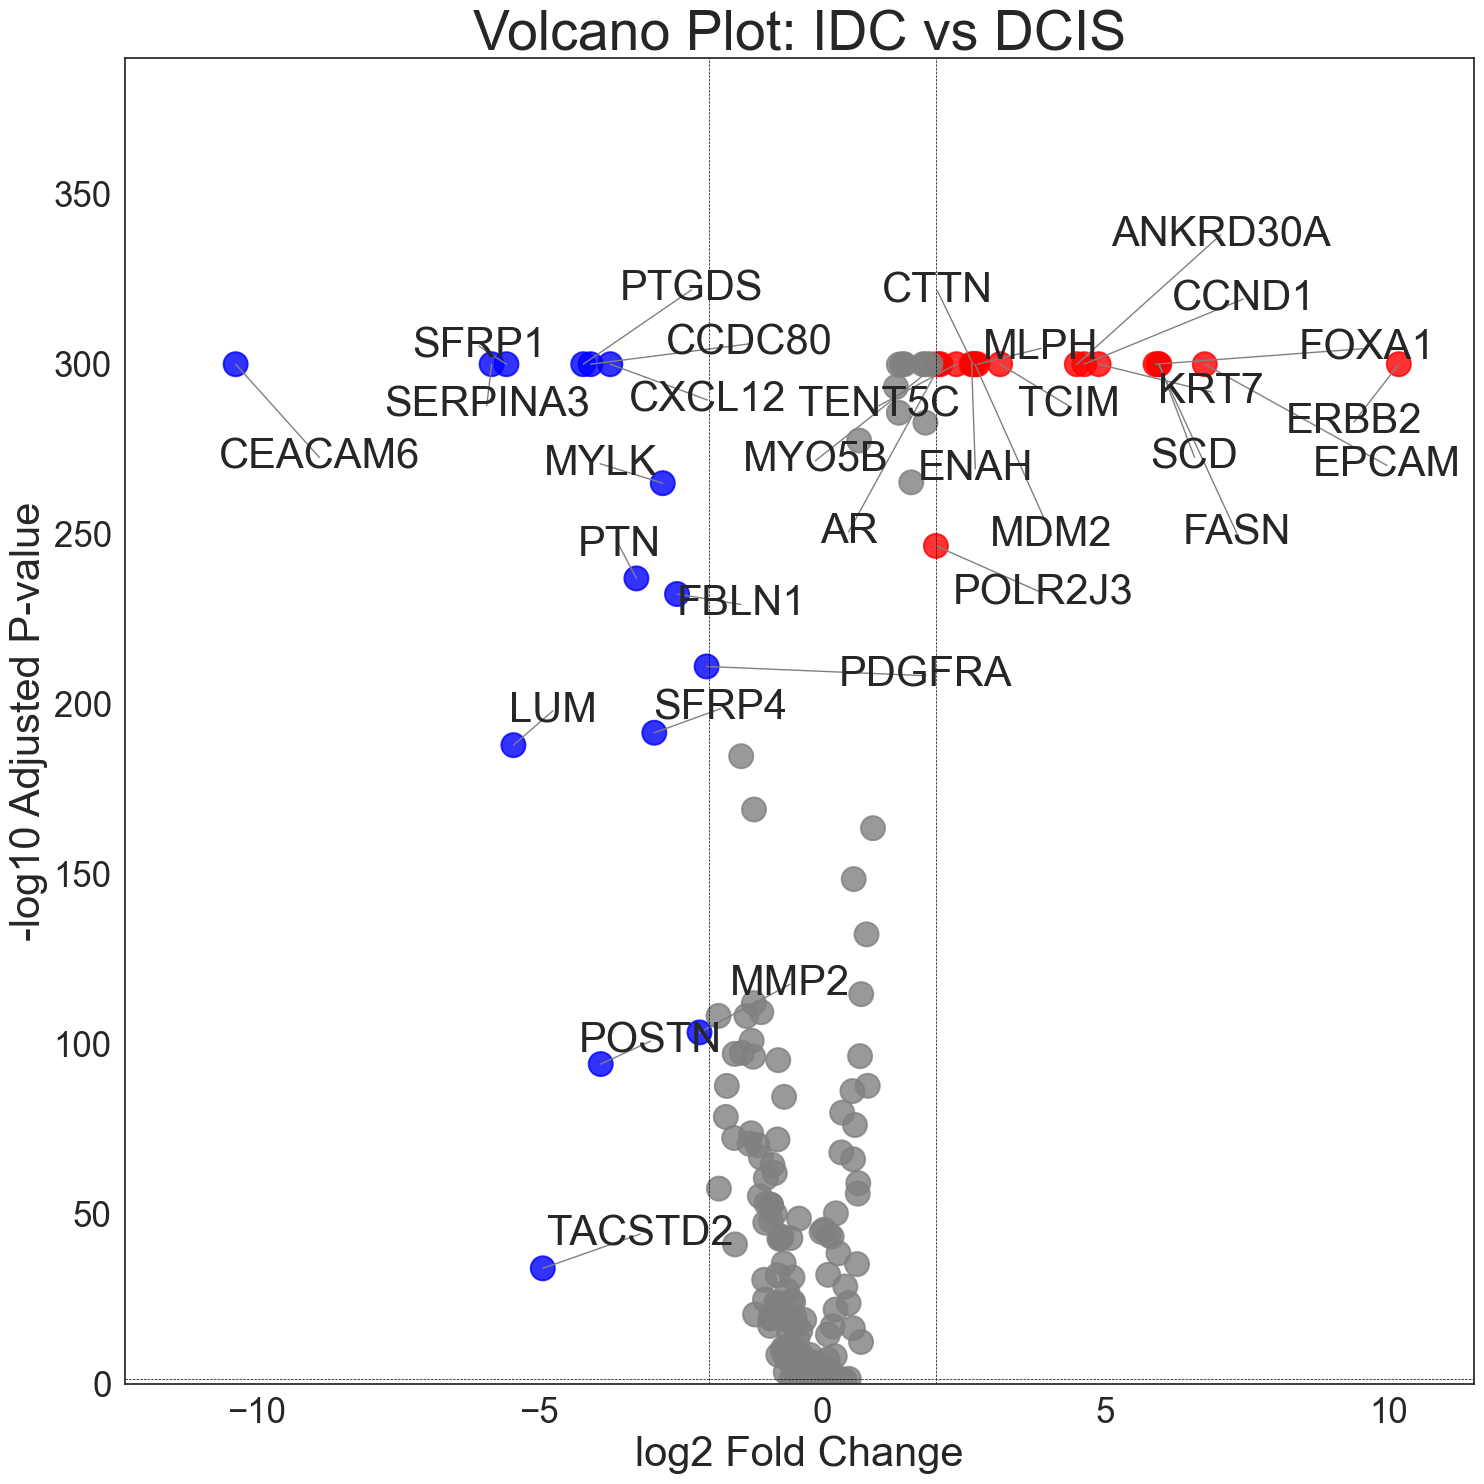

In [26]:
adata_sub = grid_deg
use_genes = ['PELI1', 'FOXA1', 'APOC1', 'NARS', 'CXCL12', 'HOOK2', 'ANKRD30A', 'CCND1', 'TCF4', 'OCIAD2', 'SCD', 'CD69', 'TRAC', 'LYPD3', 'AQP1', 'KARS', 'LUM', 'RAB30', 'TACSTD2', 'SH3YL1', 'IGF1', 'GLIPR1', 'EGFR', 'PDGFRB', 'ACTA2', 'KRT7', 'FAM107B', 'CD3E', 'CYTIP', 'POLR2J3', 'BACE2', 'PDK4', 'FBLN1', 'DSP', 'ENAH', 'VOPP1', 'SVIL', 'KLRB1', 'FSTL3', 'TRIB1', 'KRT8', 'CLDN4', 'ADGRE5', 'AKR1C1', 'EPCAM', 'HDC', 'PPARG', 'TRAPPC3', 'DUSP5', 'CCL5', 'CXCR4', 'IL7R', 'SERHL2', 'LYZ', 'TFAP2A', 'AIF1', 'FASN', 'ANKRD28', 'ITM2C', 'LDHB', 'ZEB2', 'C1QA', 'CD4', 'SEC24A', 'FCER1G', 'ERN1', 'SLAMF7', 'CTTN', 'MRC1', 'CCPG1', 'MLPH', 'RUNX1', 'ZNF562', 'CLEC14A', 'SMS', 'CEACAM6', 'ACTG2', 'PECAM1', 'PIM1', 'CCDC6', 'MMP2', 'DSC2', 'HAVCR2', 'TCIM', 'ITGAM', 'CD68', 'PTGDS', 'QARS', 'MYO5B', 'SDC4', 'IL2RG', 'PTPRC', 'WARS', 'MNDA', 'FLNB', 'ZEB1', 'DST', 'FGL2', 'PCLAF', 'AR', 'S100A14', 'TENT5C', 'LARS', 'BASP1', 'CD8A', 'FBLIM1', 'S100A4', 'HMGA1', 'JUP', 'ITGAX', 'CD3G', 'ERBB2', 'SEC11C', 'PTN', 'PRDM1', 'GPR183', 'MDM2', 'ELF3', 'EDNRB', 'CAV1', 'SERPINB9', 'DNTTIP1', 'MAP3K8', 'SLC5A6', 'CD9', 'CCDC80', 'SQLE', 'GATA3', 'BTNL9', 'PDE4A', 'SFRP1', 'RAMP2', 'PDGFRA', 'MYLK', 'CD14', 'IGSF6', 'VWF', 'CD93', 'DPT', 'POSTN', 'ADAM9', 'TOP2A', 'TPD52', 'HOXD8', 'CD247', 'SFRP4', 'SERPINA3', 'CD163', 'TRAF4', 'FCGR3A', 'KLF5', 'GZMA', 'C1QC', 'LPXN', 'CDH1', 'CRISPLD2', 'TOMM7', 'TUBA4A']

# ===========================================
# 0. Extract DE results and subset
# ===========================================
deg_df = sc.get.rank_genes_groups_df(adata_sub, group="B")
deg_df = deg_df[deg_df["names"].isin(use_genes)].copy()
deg = deg_df.copy()

# ===========================================
# 1. logFC and -log10(pval) (handle p=0)
# ===========================================
deg["logFC"] = deg["logfoldchanges"]

eps = 1e-300
deg["pvals_adj_clipped"] = deg["pvals_adj"].clip(lower=eps)
deg["-log10(pval)"] = -np.log10(deg["pvals_adj_clipped"])

# ===========================================
# 2. Color labels: up / down / ns
# ===========================================
def classify_gene(row):
    if row["pvals_adj"] < 0.05 and row["logFC"] > 2:
        return "up"
    elif row["pvals_adj"] < 0.05 and row["logFC"] < -2:
        return "down"
    else:
        return "ns"

deg["color"] = deg.apply(classify_gene, axis=1)
color_map = {"up": "red", "down": "blue", "ns": "gray"}

# ===========================================
# 3. Genes to label
# ===========================================
label_df = deg[
    (deg["color"].isin(["up", "down"])) &
    (deg["-log10(pval)"] >= 10)
]

force_labels = ["SFRP1"]
force_df = deg[deg["names"].isin(force_labels)]

high_thr = label_df["-log10(pval)"].quantile(0.8)

# ===========================================
# 4. Main plot
# ===========================================
fig, ax = plt.subplots(figsize=(15, 15))

sns.scatterplot(
    data=deg,
    x="logFC",
    y="-log10(pval)",
    hue="color",
    palette=color_map,
    edgecolor=None,
    s=300,
    alpha=0.8,
    legend=False,
    ax=ax
)

# ===========================================
# 5. Place labels (store texts and original point coordinates)
# ===========================================
texts = []
anchors_x = []   # point x coordinates (logFC)
anchors_y = []   # point y coordinates (-log10p)

# 5-1. Regular labels
for _, row in label_df.iterrows():
    gene = row["names"]
    x0 = row["logFC"]
    y0 = row["-log10(pval)"]

    # Initial label position
    x = x0
    y = y0 + 2
    if y0 >= high_thr:
        y = y0 - 20

    t = ax.text(
        x, y, gene,
        fontsize=30,
        ha='center',
        va='bottom'
    )
    texts.append(t)
    anchors_x.append(x0)
    anchors_y.append(y0)

# 5-2. Forced labels
already = set(label_df["names"])
for _, row in force_df.iterrows():
    gene = row["names"]
    if gene in already:
        continue

    x0 = row["logFC"]
    y0 = row["-log10(pval)"]

    x = x0
    y = y0 + 2
    if y0 >= high_thr:
        y = y0 - 20

    t = ax.text(
        x, y, gene,
        fontsize=30,
        ha='center',
        va='bottom',
        color="black"
    )
    texts.append(t)
    anchors_x.append(x0)
    anchors_y.append(y0)

# ===========================================
# 6. Set axis limits 
# ===========================================
xmin = deg["logFC"].min()
xmax = deg["logFC"].max()
dx = (xmax - xmin) * 0.05 if xmax > xmin else 1.0
ax.set_xlim(xmin - dx, xmax + dx)

#ymax_data = deg["-log10(pval)"].max()
#ymax0 = max(ymax_data, max(anchors_y) if anchors_y else ymax_data)
#ax.set_ylim(0, ymax0 + 40)

ymax_data = deg["-log10(pval)"].max()
headroom = max(90, ymax_data * 0.1)
ax.set_ylim(0, ymax_data + headroom)

# ===========================================
# 7. Move labels
# ===========================================
adjust_text(
    texts,
    ax=ax,
    only_move={'text': 'xy'},
    expand_text=(1.2, 1.2),
    expand_points=(1.1, 1.2),
    force_text=1.0,
    force_points=0.3,
    expand_axes=True,
    lim=500
)

# ===========================================
# 8. Draw connector lines from points to final label positions
# ===========================================
for t, x0, y0 in zip(texts, anchors_x, anchors_y):
    tx, ty = t.get_position()
    ax.plot([x0, tx], [y0, ty], '-', color='gray', lw=1)

# ===========================================
# 9. Threshold lines and styling
# ===========================================
ax.axvline(x=2,  color='black', linestyle='--', lw=0.5)
ax.axvline(x=-2, color='black', linestyle='--', lw=0.5)
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', lw=0.5)

ax.set_xlabel("log2 Fold Change", fontsize=30)
ax.set_ylabel("-log10 Adjusted P-value", fontsize=30)
ax.tick_params(axis='both', labelsize=25)

ax.set_title("Volcano Plot: IDC vs DCIS", fontsize=40)
fig.tight_layout()
plt.show()
